# Preprocessing Data Analysis Charts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

CHARTS_DIR = "D:/Python/NLP/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Charts will be saved to:", CHARTS_DIR)

Charts will be saved to: D:/Python/NLP/charts


In [2]:
# Load data
crawl_df = pd.read_csv("Day1_Crawl/ket_qua_sentence.csv")
clean_df = pd.read_csv("clean_news.csv")
print(f"Crawl: {crawl_df.shape[0]} rows")
print(f"Clean: {clean_df.shape[0]} rows")

Crawl: 3680 rows
Clean: 3167 rows


In [3]:
# Calculate statistics
crawl_df['sentence_len'] = crawl_df['Sentence'].astype(str).apply(len)
crawl_df['word_count'] = crawl_df['Sentence'].astype(str).apply(lambda x: len(x.split()))

clean_df['clean_len'] = clean_df['clean_sentence'].astype(str).apply(len)
clean_df['clean_word_count'] = clean_df['clean_sentence'].astype(str).apply(lambda x: len(str(x).split()))

comparison_df = pd.DataFrame({
    'Original_Length': crawl_df['sentence_len'].values[:len(clean_df)],
    'Clean_Length': clean_df['clean_len'].values,
    'Original_Words': crawl_df['word_count'].values[:len(clean_df)],
    'Clean_Words': clean_df['clean_word_count'].values
})

comparison_df['Length_Reduction'] = comparison_df['Original_Length'] - comparison_df['Clean_Length']
comparison_df['Length_Reduction_Pct'] = (comparison_df['Length_Reduction'] / comparison_df['Original_Length'] * 100)
comparison_df['Word_Reduction'] = comparison_df['Original_Words'] - comparison_df['Clean_Words']
comparison_df['Word_Reduction_Pct'] = (comparison_df['Word_Reduction'] / comparison_df['Original_Words'] * 100)

print("Comparison Statistics:")
print(comparison_df.describe())

Comparison Statistics:
       Original_Length  Clean_Length  Original_Words  Clean_Words  \
count      3167.000000   3167.000000     3167.000000  3167.000000   
mean        158.977897    116.132933       25.839912    15.968109   
std          91.305784     62.367259       14.585382     8.338272   
min          41.000000     28.000000        5.000000     6.000000   
25%          98.000000     73.000000       16.000000    10.000000   
50%         143.000000    105.000000       23.000000    15.000000   
75%         199.000000    147.000000       32.000000    20.000000   
max        2033.000000   1600.000000      326.000000   224.000000   

       Length_Reduction  Length_Reduction_Pct  Word_Reduction  \
count       3167.000000           3167.000000     3167.000000   
mean          42.844964              5.046262        9.871803   
std          110.809798             79.336727       16.840693   
min        -1516.000000          -1804.761905     -208.000000   
25%          -20.000000       

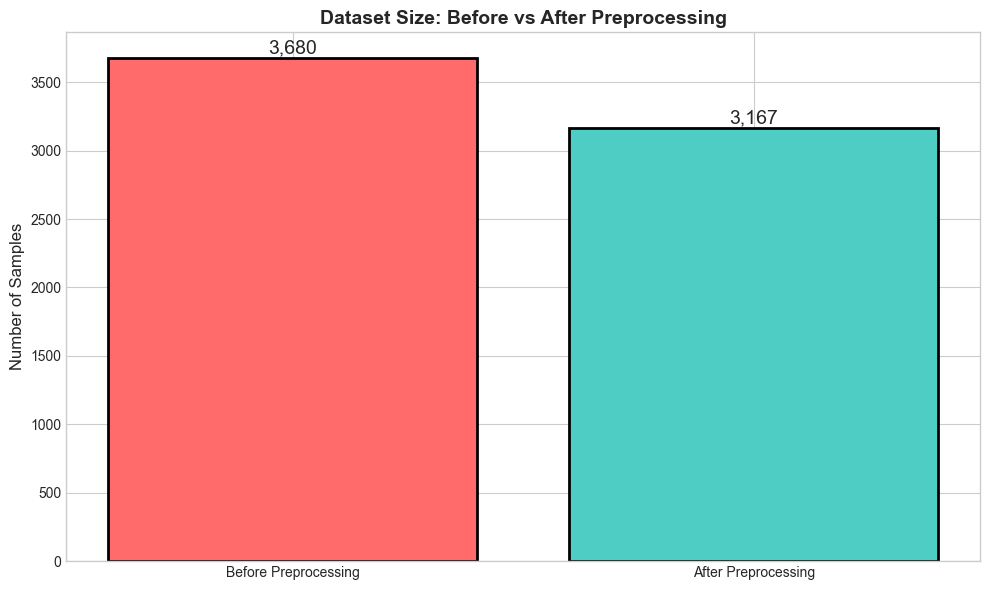

In [4]:
# Chart 1: Dataset Size
fig, ax = plt.subplots(figsize=(10, 6))
stages = ['Before Preprocessing', 'After Preprocessing']
sizes = [crawl_df.shape[0], clean_df.shape[0]]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax.bar(stages, sizes, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Dataset Size: Before vs After Preprocessing', fontsize=14, fontweight='bold')
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{size:,}', ha='center', fontsize=14)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_01_dataset_size.png", dpi=150, bbox_inches='tight')
plt.show()

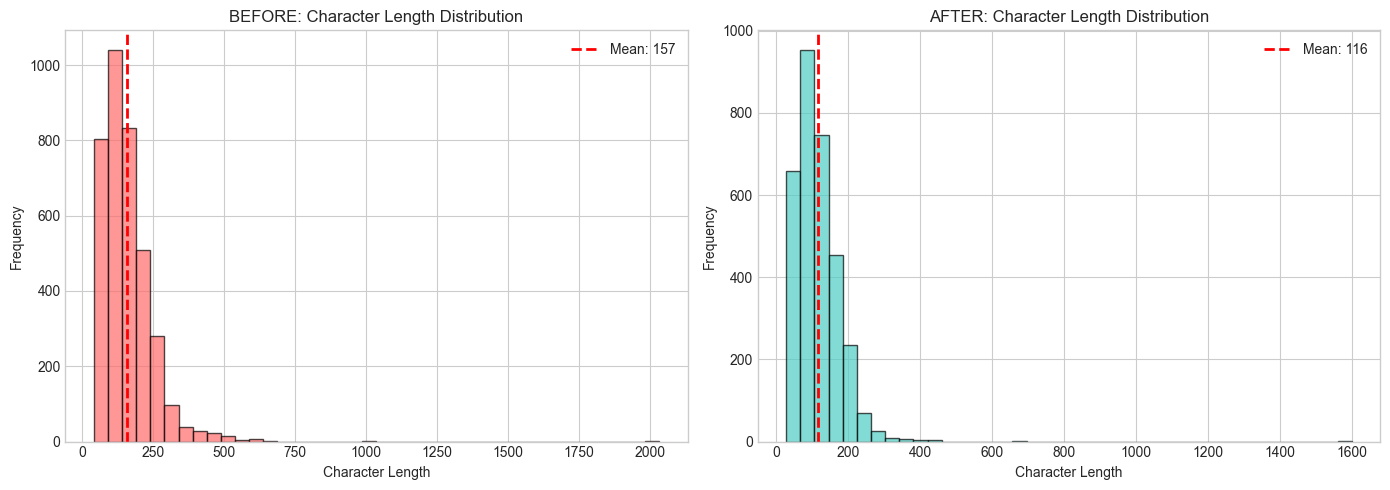

In [5]:
# Chart 2: Character Length Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(crawl_df['sentence_len'], bins=40, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0].axvline(crawl_df['sentence_len'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {crawl_df['sentence_len'].mean():.0f}")
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BEFORE: Character Length Distribution')
axes[0].legend()

axes[1].hist(clean_df['clean_len'], bins=40, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[1].axvline(clean_df['clean_len'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {clean_df['clean_len'].mean():.0f}")
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].set_title('AFTER: Character Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_02_char_length.png", dpi=150, bbox_inches='tight')
plt.show()

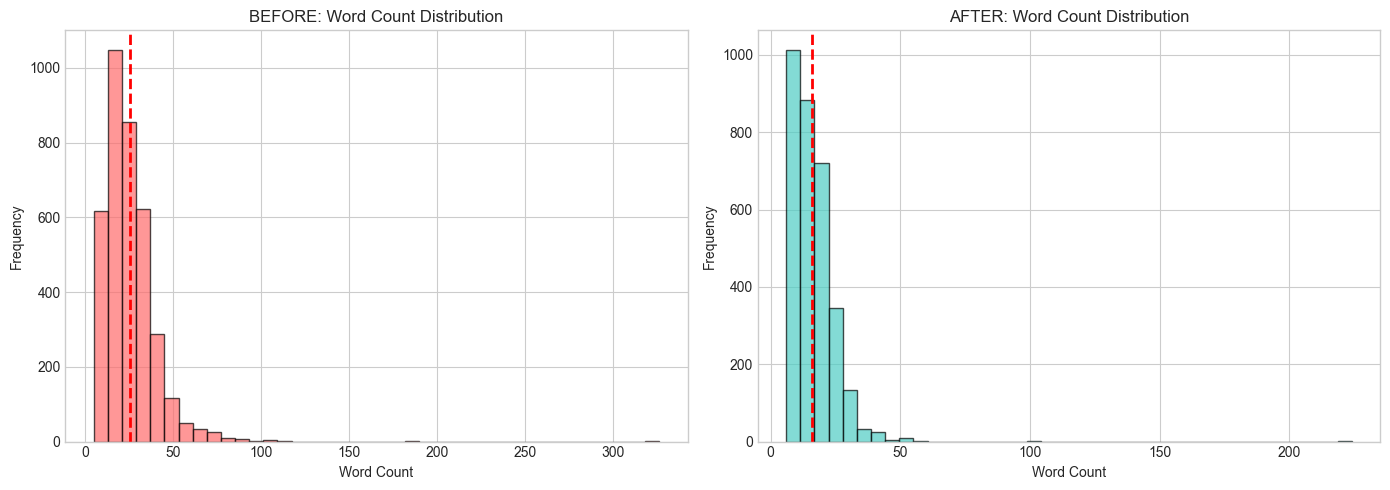

In [6]:
# Chart 3: Word Count Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(crawl_df['word_count'], bins=40, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0].axvline(crawl_df['word_count'].mean(), color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BEFORE: Word Count Distribution')

axes[1].hist(clean_df['clean_word_count'], bins=40, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[1].axvline(clean_df['clean_word_count'].mean(), color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('AFTER: Word Count Distribution')

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_03_word_count.png", dpi=150, bbox_inches='tight')
plt.show()

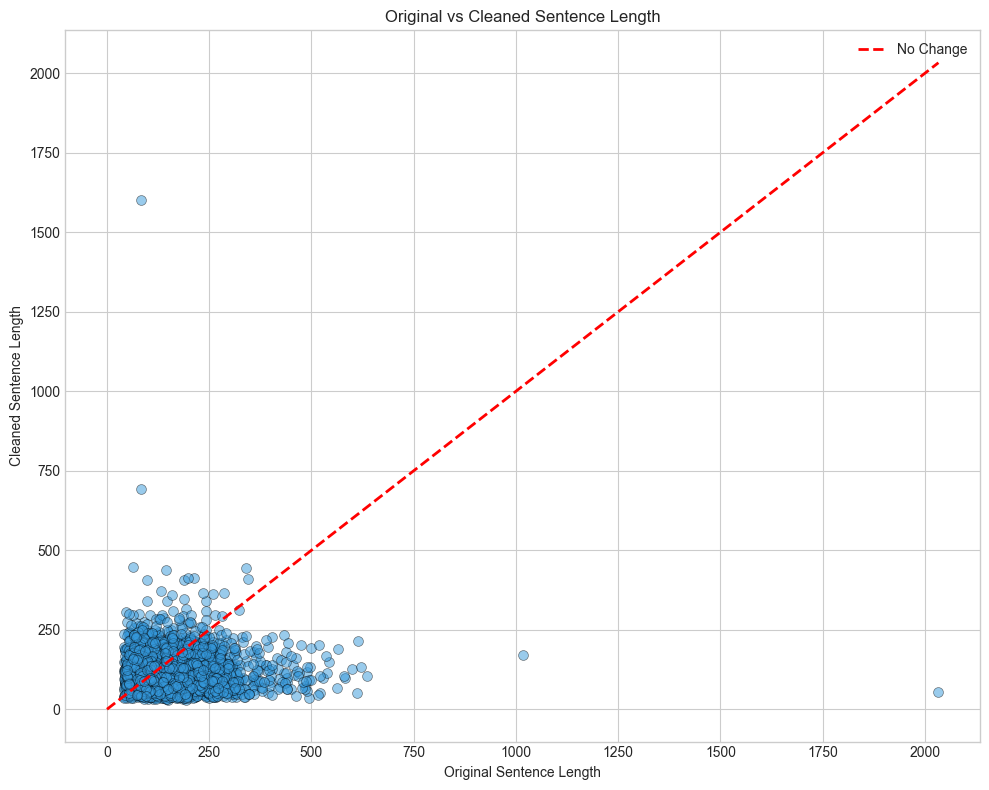

In [7]:
# Chart 4: Before vs After Scatter
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(comparison_df['Original_Length'], comparison_df['Clean_Length'], alpha=0.5, c='#3498DB', edgecolors='black', linewidth=0.5, s=50)
max_val = max(comparison_df['Original_Length'].max(), comparison_df['Clean_Length'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='No Change')
ax.set_xlabel('Original Sentence Length')
ax.set_ylabel('Cleaned Sentence Length')
ax.set_title('Original vs Cleaned Sentence Length')
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_04_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

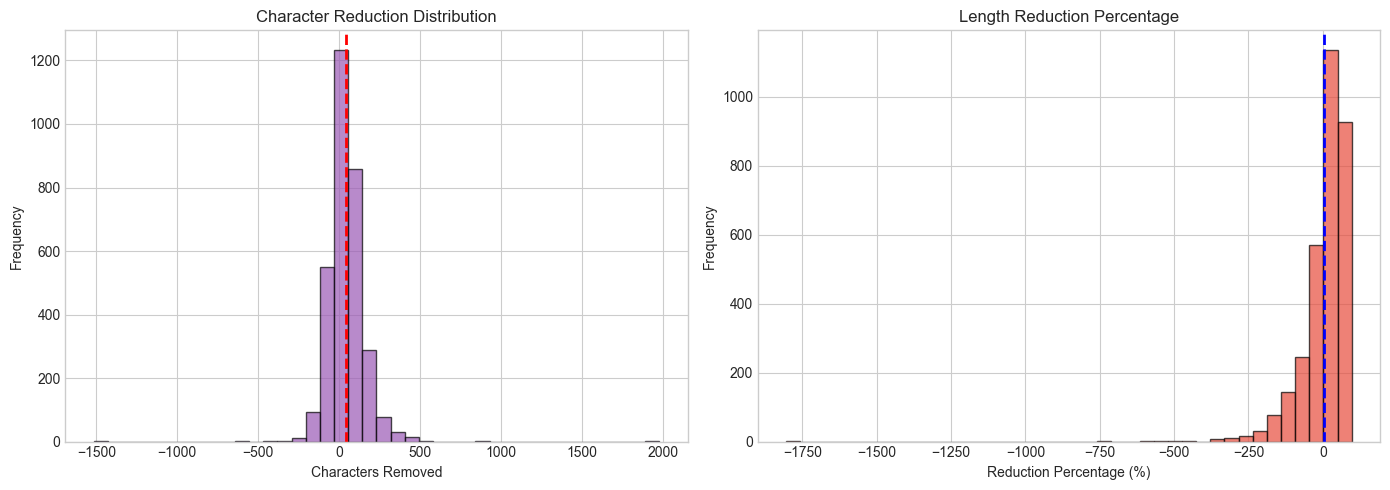

In [8]:
# Chart 5: Length Reduction Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(comparison_df['Length_Reduction'], bins=40, color='#9B59B6', edgecolor='black', alpha=0.7)
axes[0].axvline(comparison_df['Length_Reduction'].mean(), color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Characters Removed')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Character Reduction Distribution')

axes[1].hist(comparison_df['Length_Reduction_Pct'], bins=40, color='#E74C3C', edgecolor='black', alpha=0.7)
axes[1].axvline(comparison_df['Length_Reduction_Pct'].mean(), color='blue', linestyle='--', linewidth=2)
axes[1].set_xlabel('Reduction Percentage (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Length Reduction Percentage')

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_05_reduction.png", dpi=150, bbox_inches='tight')
plt.show()

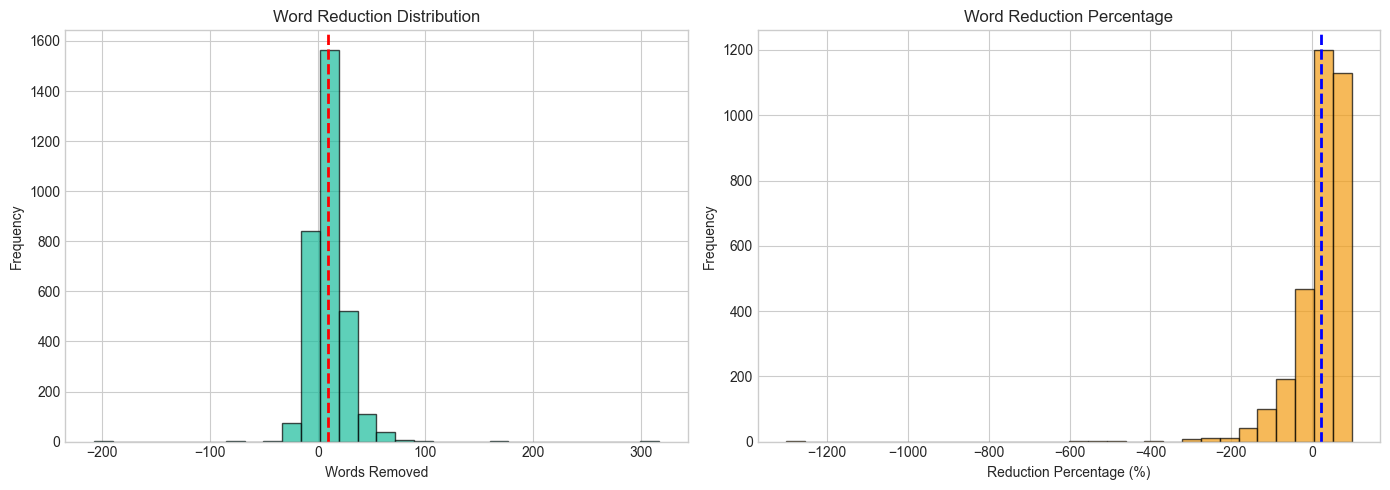

In [9]:
# Chart 6: Word Reduction Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(comparison_df['Word_Reduction'], bins=30, color='#1ABC9C', edgecolor='black', alpha=0.7)
axes[0].axvline(comparison_df['Word_Reduction'].mean(), color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Words Removed')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Reduction Distribution')

axes[1].hist(comparison_df['Word_Reduction_Pct'], bins=30, color='#F39C12', edgecolor='black', alpha=0.7)
axes[1].axvline(comparison_df['Word_Reduction_Pct'].mean(), color='blue', linestyle='--', linewidth=2)
axes[1].set_xlabel('Reduction Percentage (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Word Reduction Percentage')

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_06_word_reduction.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_21476\903301722.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot([crawl_df['sentence_len'].values[:len(clean_df)], clean_df['clean_len'].values], labels=['Before', 'After'], patch_artist=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_21476\903301722.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([crawl_df['word_count'].values[:len(clean_df)], clean_df['clean_word_count'].values], labels=['Before', 'After'], patch_artist=True)


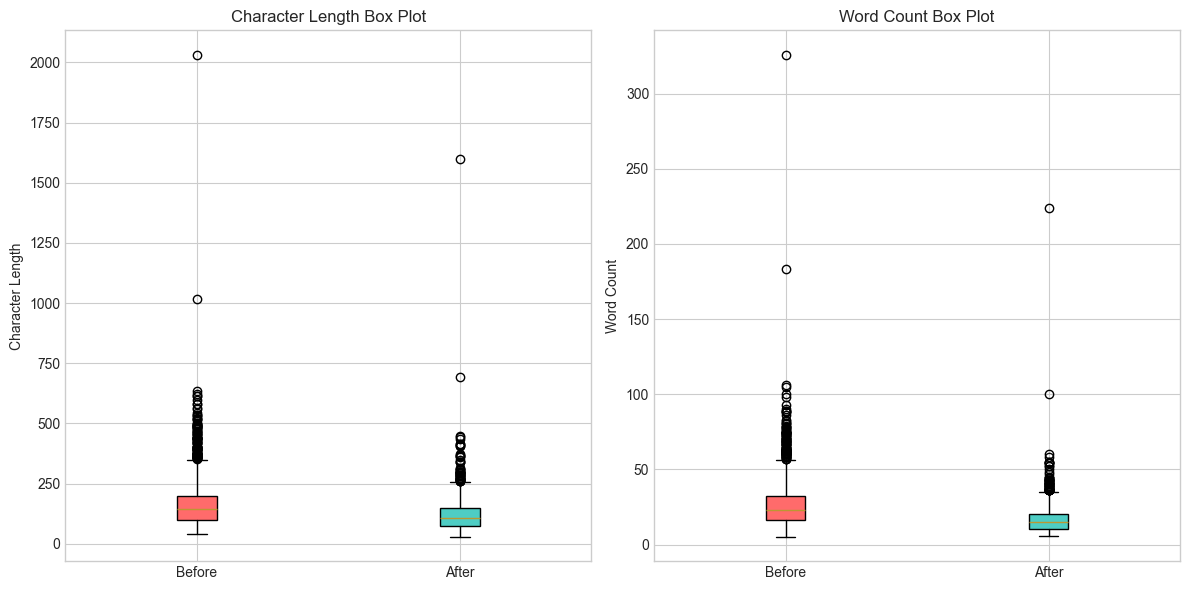

In [10]:
# Chart 7: Box Plot Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
bp1 = axes[0].boxplot([crawl_df['sentence_len'].values[:len(clean_df)], clean_df['clean_len'].values], labels=['Before', 'After'], patch_artist=True)
bp1['boxes'][0].set_facecolor('#FF6B6B')
bp1['boxes'][1].set_facecolor('#4ECDC4')
axes[0].set_ylabel('Character Length')
axes[0].set_title('Character Length Box Plot')

bp2 = axes[1].boxplot([crawl_df['word_count'].values[:len(clean_df)], clean_df['clean_word_count'].values], labels=['Before', 'After'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#FF6B6B')
bp2['boxes'][1].set_facecolor('#4ECDC4')
axes[1].set_ylabel('Word Count')
axes[1].set_title('Word Count Box Plot')

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_07_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_21476\779926481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Stage', y='Length', data=data_char, ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
C:\Users\pc\AppData\Local\Temp\ipykernel_21476\779926481.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Stage', y='Count', data=data_word, ax=axes[1], palette=['#FF6B6B', '#4ECDC4'])


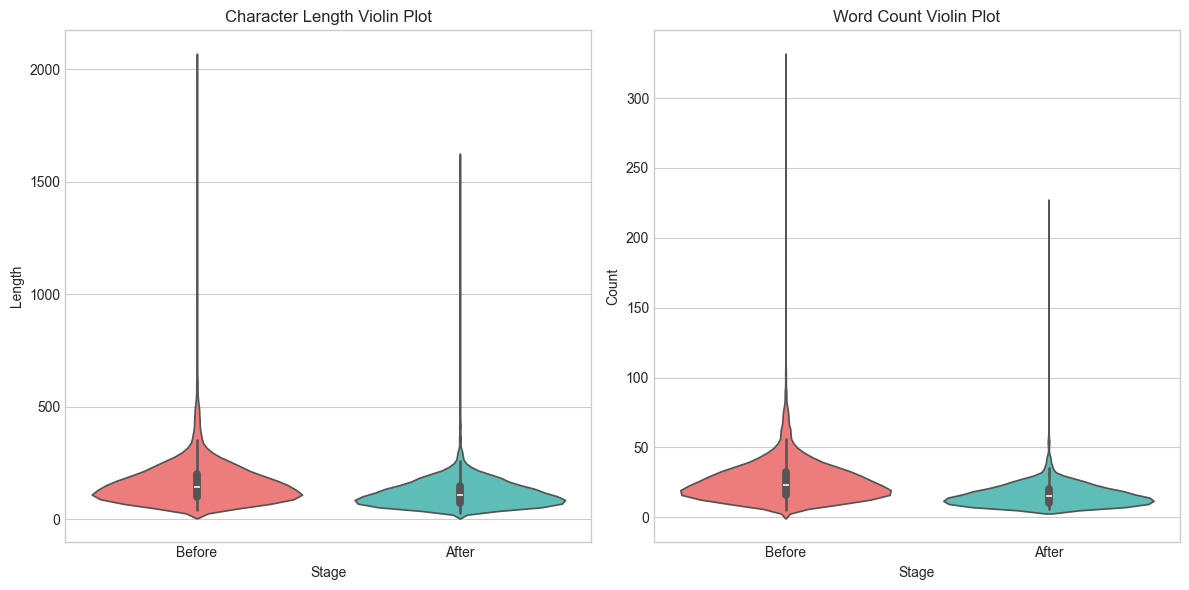

In [11]:
# Chart 8: Violin Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
data_char = pd.DataFrame({'Length': list(crawl_df['sentence_len'].values[:len(clean_df)]) + list(clean_df['clean_len'].values), 'Stage': ['Before']*len(clean_df) + ['After']*len(clean_df)})
sns.violinplot(x='Stage', y='Length', data=data_char, ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Character Length Violin Plot')

data_word = pd.DataFrame({'Count': list(crawl_df['word_count'].values[:len(clean_df)]) + list(clean_df['clean_word_count'].values), 'Stage': ['Before']*len(clean_df) + ['After']*len(clean_df)})
sns.violinplot(x='Stage', y='Count', data=data_word, ax=axes[1], palette=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Word Count Violin Plot')

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_08_violin.png", dpi=150, bbox_inches='tight')
plt.show()

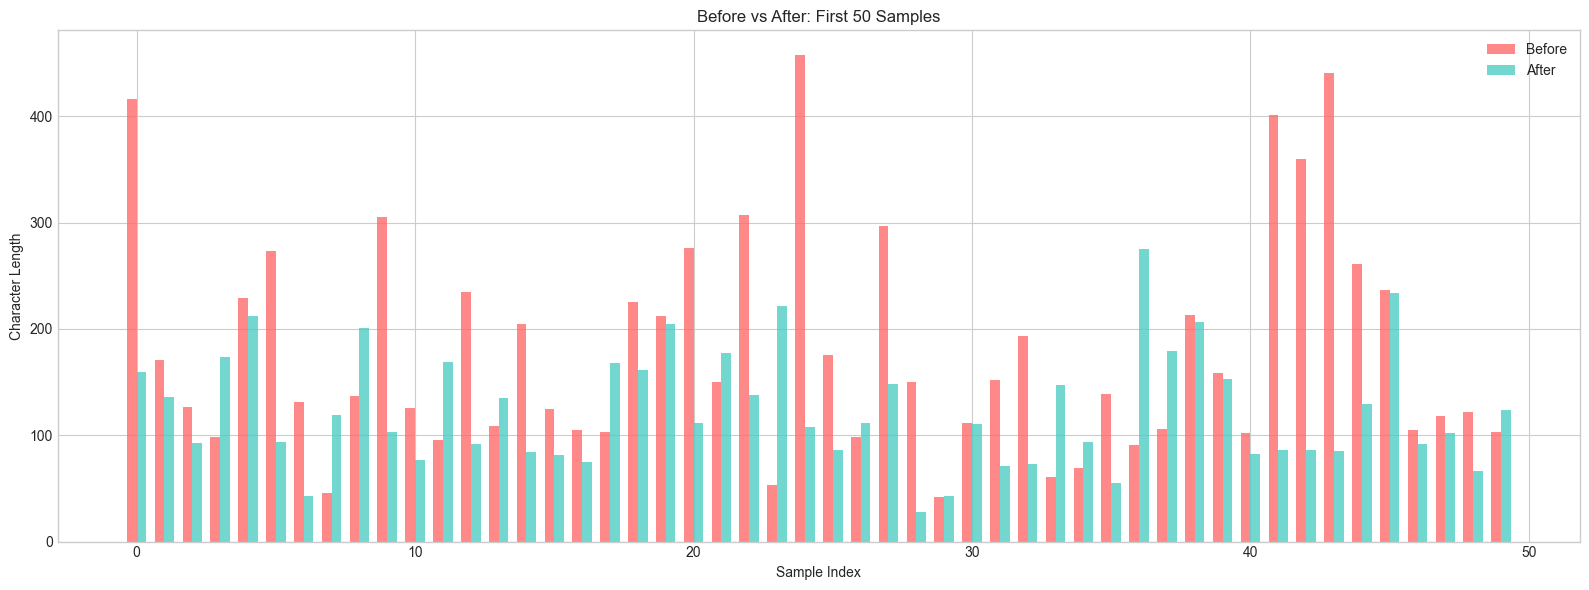

In [12]:
# Chart 9: Sample Comparison (First 50)
n_samples = 50
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(n_samples)
width = 0.35
bars1 = ax.bar(x - width/2, comparison_df['Original_Length'].values[:n_samples], width, label='Before', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['Clean_Length'].values[:n_samples], width, label='After', color='#4ECDC4', alpha=0.8)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Character Length')
ax.set_title('Before vs After: First 50 Samples')
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_09_samples.png", dpi=150, bbox_inches='tight')
plt.show()

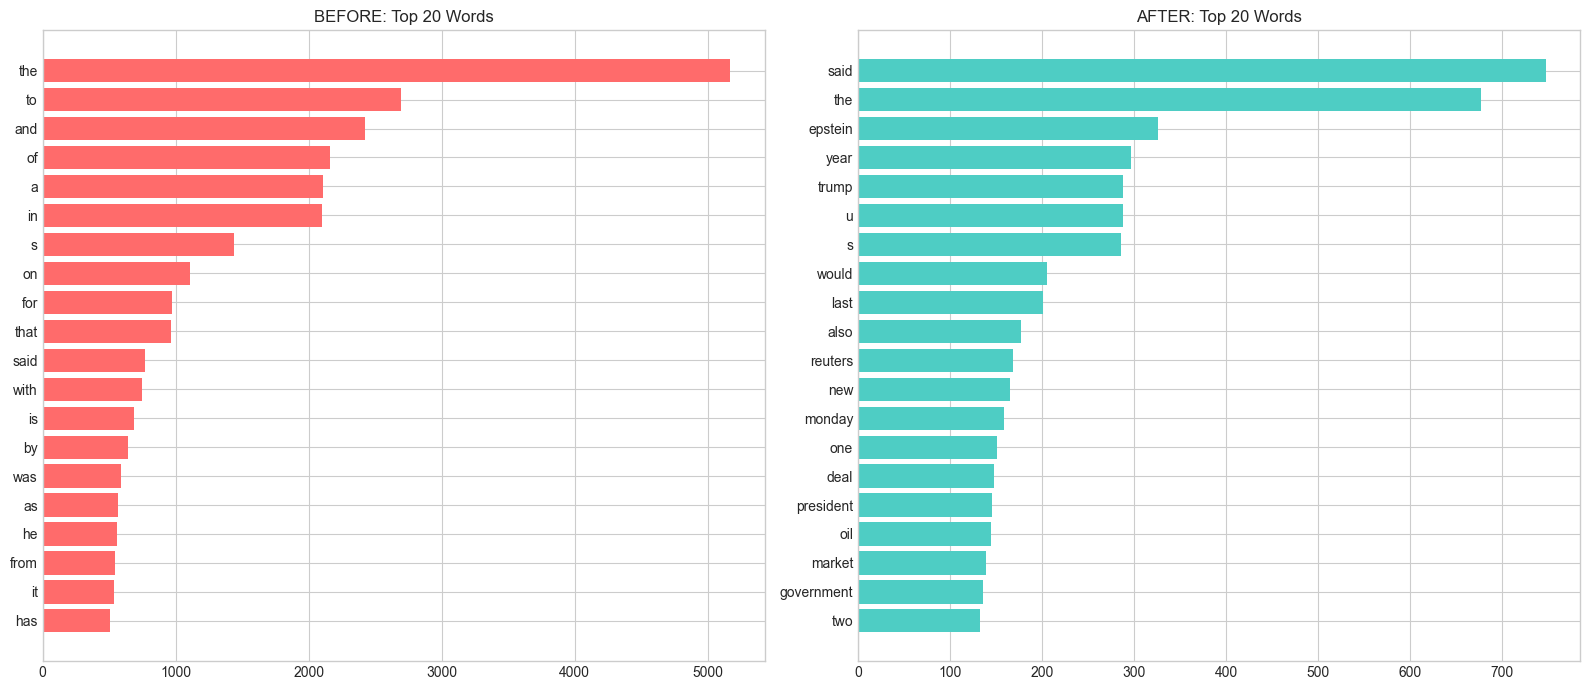

In [13]:
# Chart 10: Word Frequency Comparison
before_text = ' '.join(crawl_df['Sentence'].astype(str).tolist()).lower()
after_text = ' '.join(clean_df['clean_sentence'].astype(str).tolist()).lower()
before_words = Counter(re.findall(r'\b[a-z]+\b', before_text))
after_words = Counter(re.findall(r'\b[a-z]+\b', after_text))

top_before = before_words.most_common(20)
top_after = after_words.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh([w[0] for w in top_before][::-1], [w[1] for w in top_before][::-1], color='#FF6B6B')
axes[0].set_title('BEFORE: Top 20 Words')
axes[1].barh([w[0] for w in top_after][::-1], [w[1] for w in top_after][::-1], color='#4ECDC4')
axes[1].set_title('AFTER: Top 20 Words')
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_10_words.png", dpi=150, bbox_inches='tight')
plt.show()

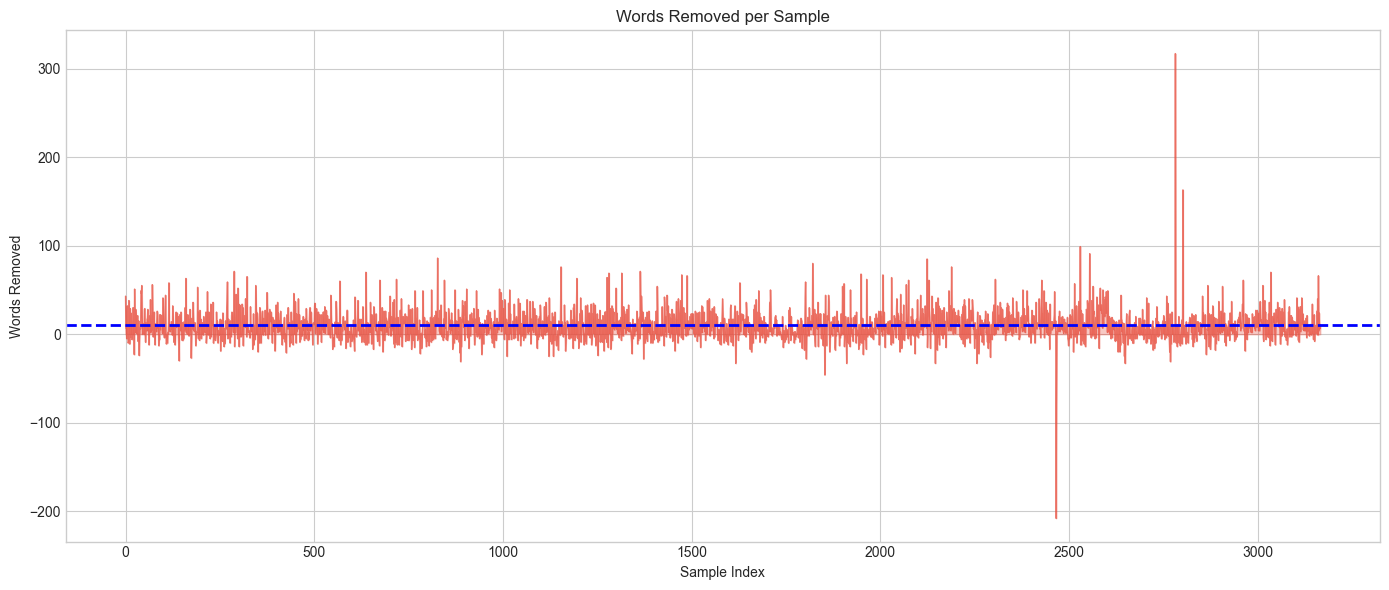

In [14]:
# Chart 11: Word Reduction per Sample
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(len(comparison_df)), comparison_df['Word_Reduction'].values, color='#E74C3C', alpha=0.7, linewidth=1)
ax.axhline(y=comparison_df['Word_Reduction'].mean(), color='blue', linestyle='--', linewidth=2)
ax.fill_between(range(len(comparison_df)), comparison_df['Word_Reduction'].values, alpha=0.3, color='#E74C3C')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Words Removed')
ax.set_title('Words Removed per Sample')
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_11_word_removed.png", dpi=150, bbox_inches='tight')
plt.show()

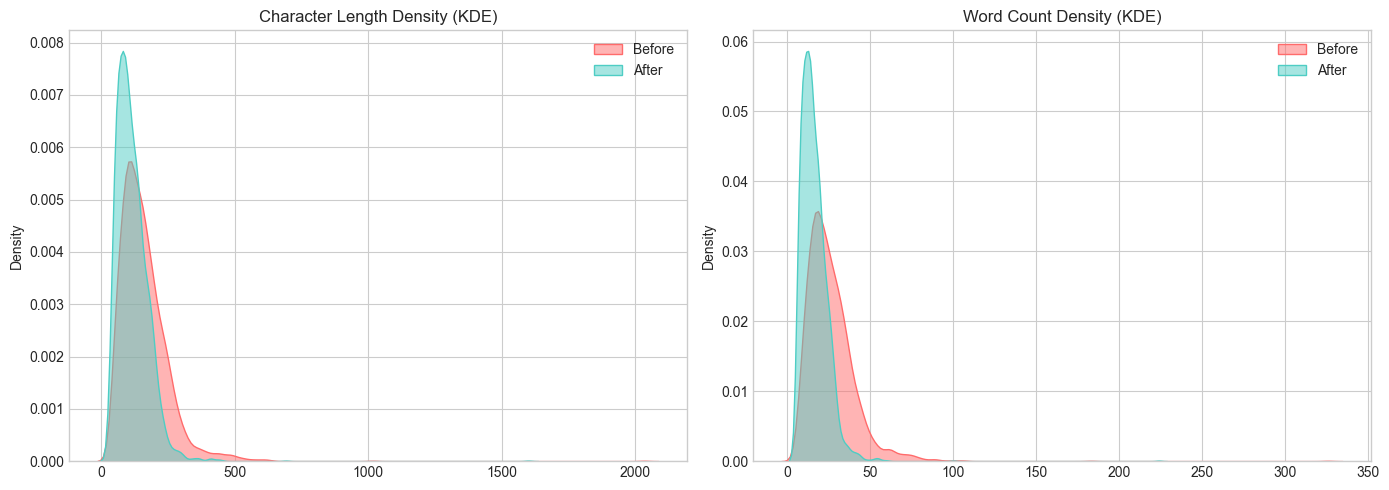

In [15]:
# Chart 12: KDE Density Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(crawl_df['sentence_len'].values[:len(clean_df)], ax=axes[0], color='#FF6B6B', fill=True, alpha=0.5, label='Before')
sns.kdeplot(clean_df['clean_len'].values, ax=axes[0], color='#4ECDC4', fill=True, alpha=0.5, label='After')
axes[0].set_title('Character Length Density (KDE)')
axes[0].legend()

sns.kdeplot(crawl_df['word_count'].values[:len(clean_df)], ax=axes[1], color='#FF6B6B', fill=True, alpha=0.5, label='Before')
sns.kdeplot(clean_df['clean_word_count'].values, ax=axes[1], color='#4ECDC4', fill=True, alpha=0.5, label='After')
axes[1].set_title('Word Count Density (KDE)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_12_kde.png", dpi=150, bbox_inches='tight')
plt.show()

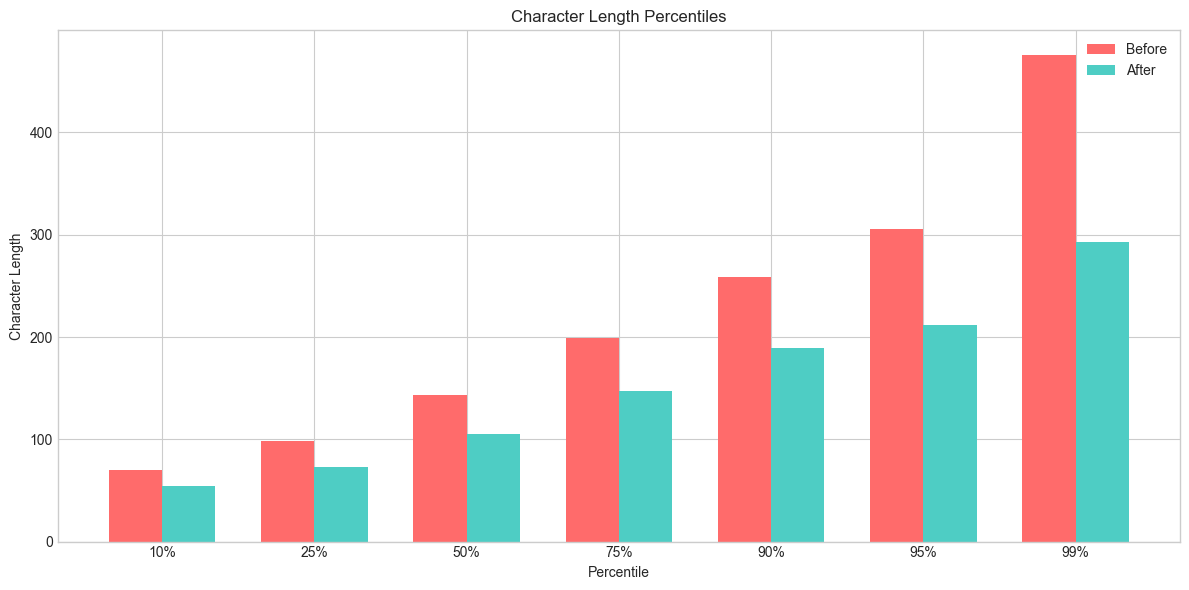

In [16]:
# Chart 13: Percentiles Comparison
percentiles = [10, 25, 50, 75, 90, 95, 99]
before_pct = [np.percentile(crawl_df['sentence_len'].values[:len(clean_df)], p) for p in percentiles]
after_pct = [np.percentile(clean_df['clean_len'].values, p) for p in percentiles]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(percentiles))
width = 0.35
ax.bar(x - width/2, before_pct, width, label='Before', color='#FF6B6B')
ax.bar(x + width/2, after_pct, width, label='After', color='#4ECDC4')
ax.set_xlabel('Percentile')
ax.set_ylabel('Character Length')
ax.set_title('Character Length Percentiles')
ax.set_xticks(x)
ax.set_xticklabels([f'{p}%' for p in percentiles])
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_13_percentiles.png", dpi=150, bbox_inches='tight')
plt.show()

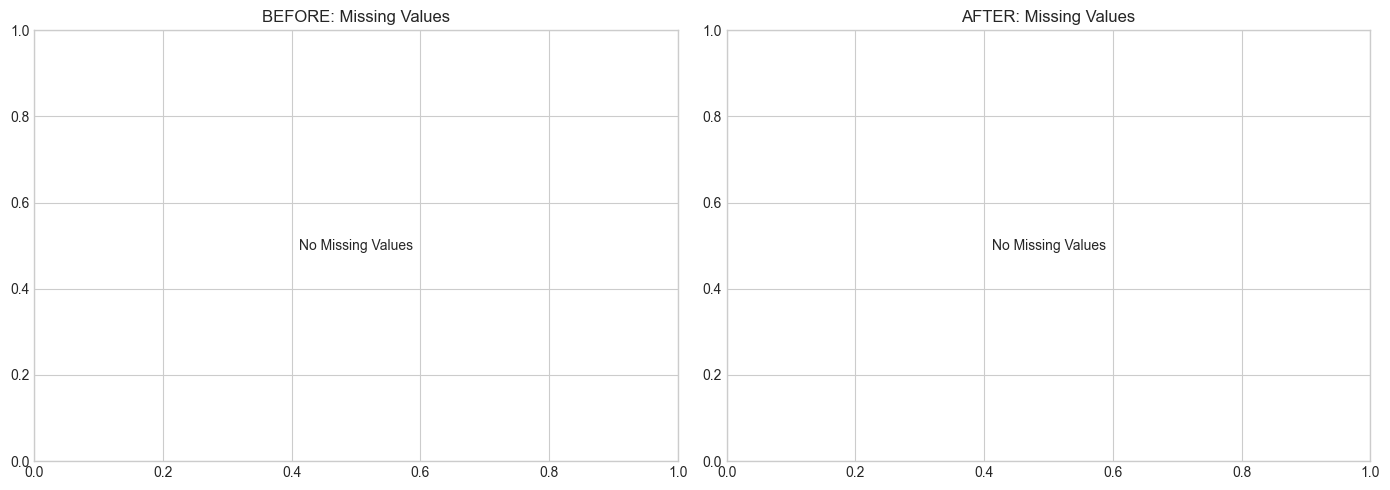

In [17]:
# Chart 14: Missing Values
before_missing = crawl_df.isnull().sum()
after_missing = clean_df.isnull().sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_b = before_missing[before_missing > 0]
if len(missing_b) > 0:
    axes[0].bar(missing_b.index, missing_b.values, color='#FF6B6B')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center')
axes[0].set_title('BEFORE: Missing Values')

missing_a = after_missing[after_missing > 0]
if len(missing_a) > 0:
    axes[1].bar(missing_a.index, missing_a.values, color='#4ECDC4')
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center', va='center')
axes[1].set_title('AFTER: Missing Values')

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_14_missing.png", dpi=150, bbox_inches='tight')
plt.show()

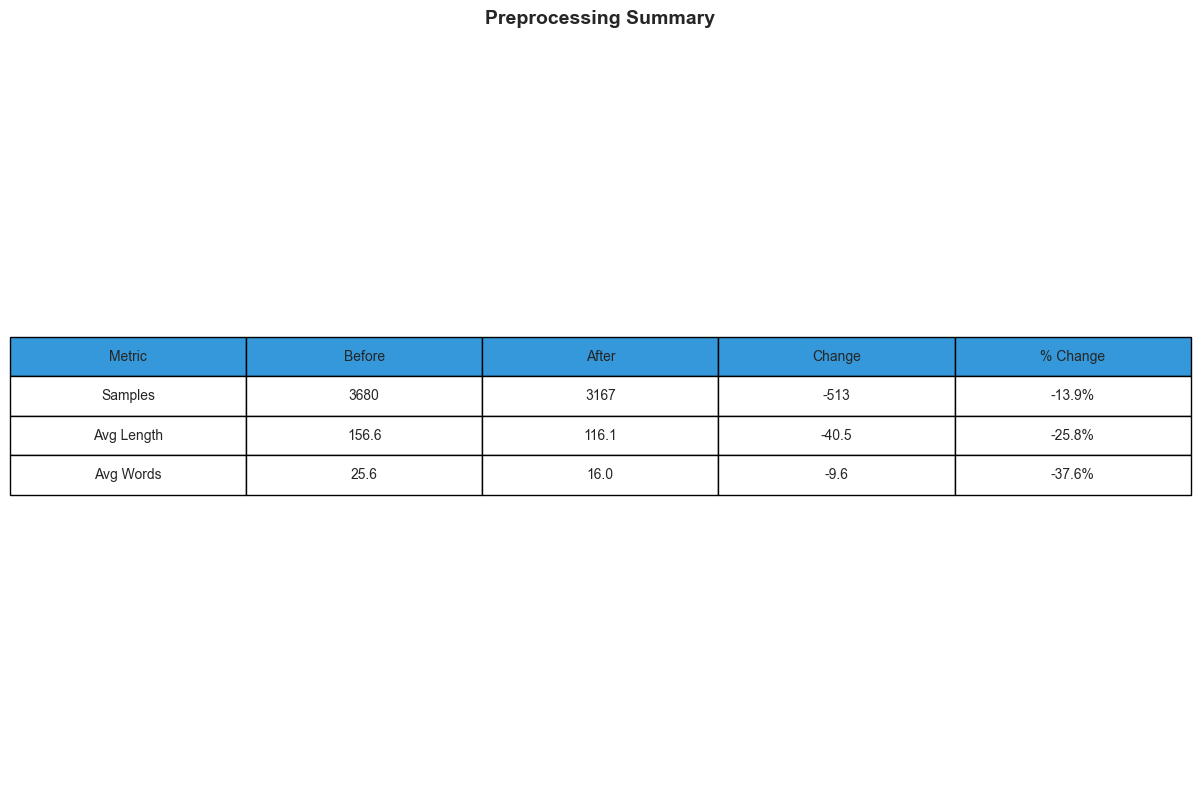

All preprocessing charts saved to: D:/Python/NLP/charts


In [18]:
# Chart 15: Summary Table
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

summary = [
    ['Metric', 'Before', 'After', 'Change', '% Change'],
    ['Samples', str(crawl_df.shape[0]), str(clean_df.shape[0]), str(clean_df.shape[0]-crawl_df.shape[0]), f'{(clean_df.shape[0]-crawl_df.shape[0])/crawl_df.shape[0]*100:.1f}%'],
    ['Avg Length', f'{crawl_df["sentence_len"].mean():.1f}', f'{clean_df["clean_len"].mean():.1f}', f'{clean_df["clean_len"].mean()-crawl_df["sentence_len"].mean():.1f}', f'{(clean_df["clean_len"].mean()-crawl_df["sentence_len"].mean())/crawl_df["sentence_len"].mean()*100:.1f}%'],
    ['Avg Words', f'{crawl_df["word_count"].mean():.1f}', f'{clean_df["clean_word_count"].mean():.1f}', f'{clean_df["clean_word_count"].mean()-crawl_df["word_count"].mean():.1f}', f'{(clean_df["clean_word_count"].mean()-crawl_df["word_count"].mean())/crawl_df["word_count"].mean()*100:.1f}%'],
]

table = ax.table(cellText=summary[1:], colLabels=summary[0], loc='center', cellLoc='center', colColours=['#3498DB']*5)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)
ax.set_title('Preprocessing Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/preprocess_15_summary.png", dpi=150, bbox_inches='tight')
plt.show()

print("All preprocessing charts saved to:", CHARTS_DIR)